In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import pickle
from tqdm import tqdm
import logging

import numpy as np

sys.path.append("..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

In [3]:
dif_names = ["ModelO", "ModelA", "ModelF"]
blg_names = ["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"]

samples_expand_keys = {
    'theta_pib' : [f'theta_pib_{n}' for n in dif_names],
    'theta_ics' : [f'theta_ics_{n}' for n in dif_names],
    'theta_bulge_poiss' : [f'theta_poiss_{n}' for n in blg_names],
    'theta_bulge_ps' : [f'theta_ps_{n}' for n in blg_names],
}

def expand_samples(samples):
    new_samples = {}
    for k in samples.keys():
        if k in samples_expand_keys:
            for i in range(samples[k].shape[-1]):
                new_samples[samples_expand_keys[k][i]] = samples[k][...,i]
        elif k in ['auto_shared_latent']:
            pass
        else:
            new_samples[k] = samples[k]
    return new_samples

In [4]:
save_dir = "../outputs/np_p_230827"
n_run = 28

truth_dict = expand_samples(pickle.load(open(f"{save_dir}/truth.p", "rb")))
truth_dict = {k : v for k, v in truth_dict.items() if v != 0}

roc_runs = {k : [] for k in truth_dict.keys()}
for i_run in tqdm(range(n_run)):
    samples = pickle.load(open(f"{save_dir}/svi_samples_{i_run}.p", "rb"))
    for k, v in truth_dict.items():
        if k == 'S_dsk':
            continue
        samples_k = np.array(samples[k])
        roc_runs[k].append(find_hdi_prob(samples_k, v, level=15))
for k in roc_runs.keys():
    roc_runs[k] = np.sort(roc_runs[k])

  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:03<00:00,  7.48it/s]


In [5]:
roc_runs['theta_pib_ModelO']

array([4.57763672e-05, 1.25076294e-01, 2.14981079e-01, 3.89816284e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01,
       9.99984741e-01, 9.99984741e-01, 9.99984741e-01, 9.99984741e-01])

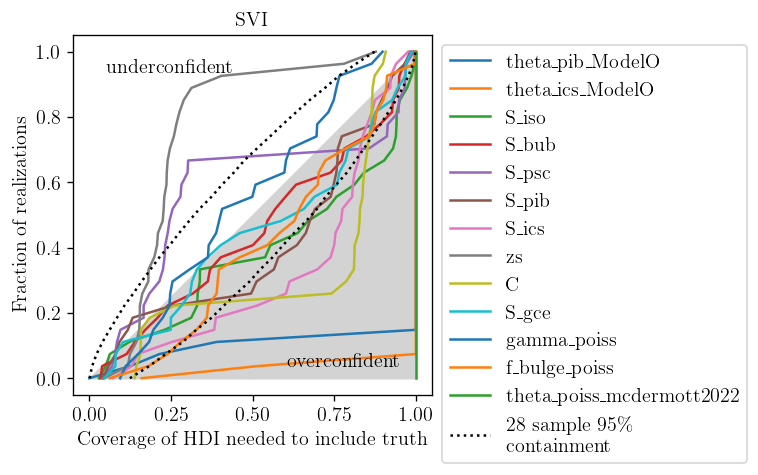

In [4]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for k, roc in roc_runs.items():
    ax.plot(roc, np.linspace(0, 1, n_run), label=k)

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'SVI')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
#plt.savefig(f"fit_np_to_p/roc.pdf")

## Check posterior

In [9]:
! ls ../outputs

np_np_230830  np_np_psonly_230902  np_p_230827	slurm  svi_p_p_230826


In [13]:
svi_samples = pickle.load(open('../outputs/np_p_230827/svi_samples_0.p', 'rb'))
hmc_samples = expand_samples(pickle.load(open('../outputs/np_p_230827/hmc_samples_0.p', 'rb')))
truth_dict = expand_samples(pickle.load(open('../outputs/np_p_230827/truth.p', 'rb')))

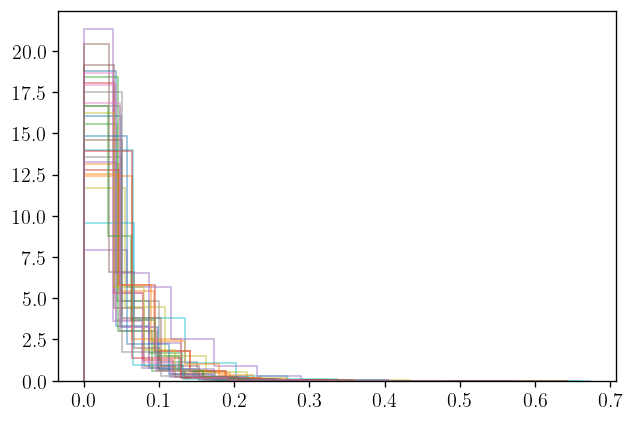

In [2]:
for i in range(28):
    svi_samples = pickle.load(open(f'../outputs/np_p_230827/svi_samples_{i}.p', 'rb'))
    plt.hist(svi_samples['Sps_gce'], density=True, alpha=0.5, histtype='step')

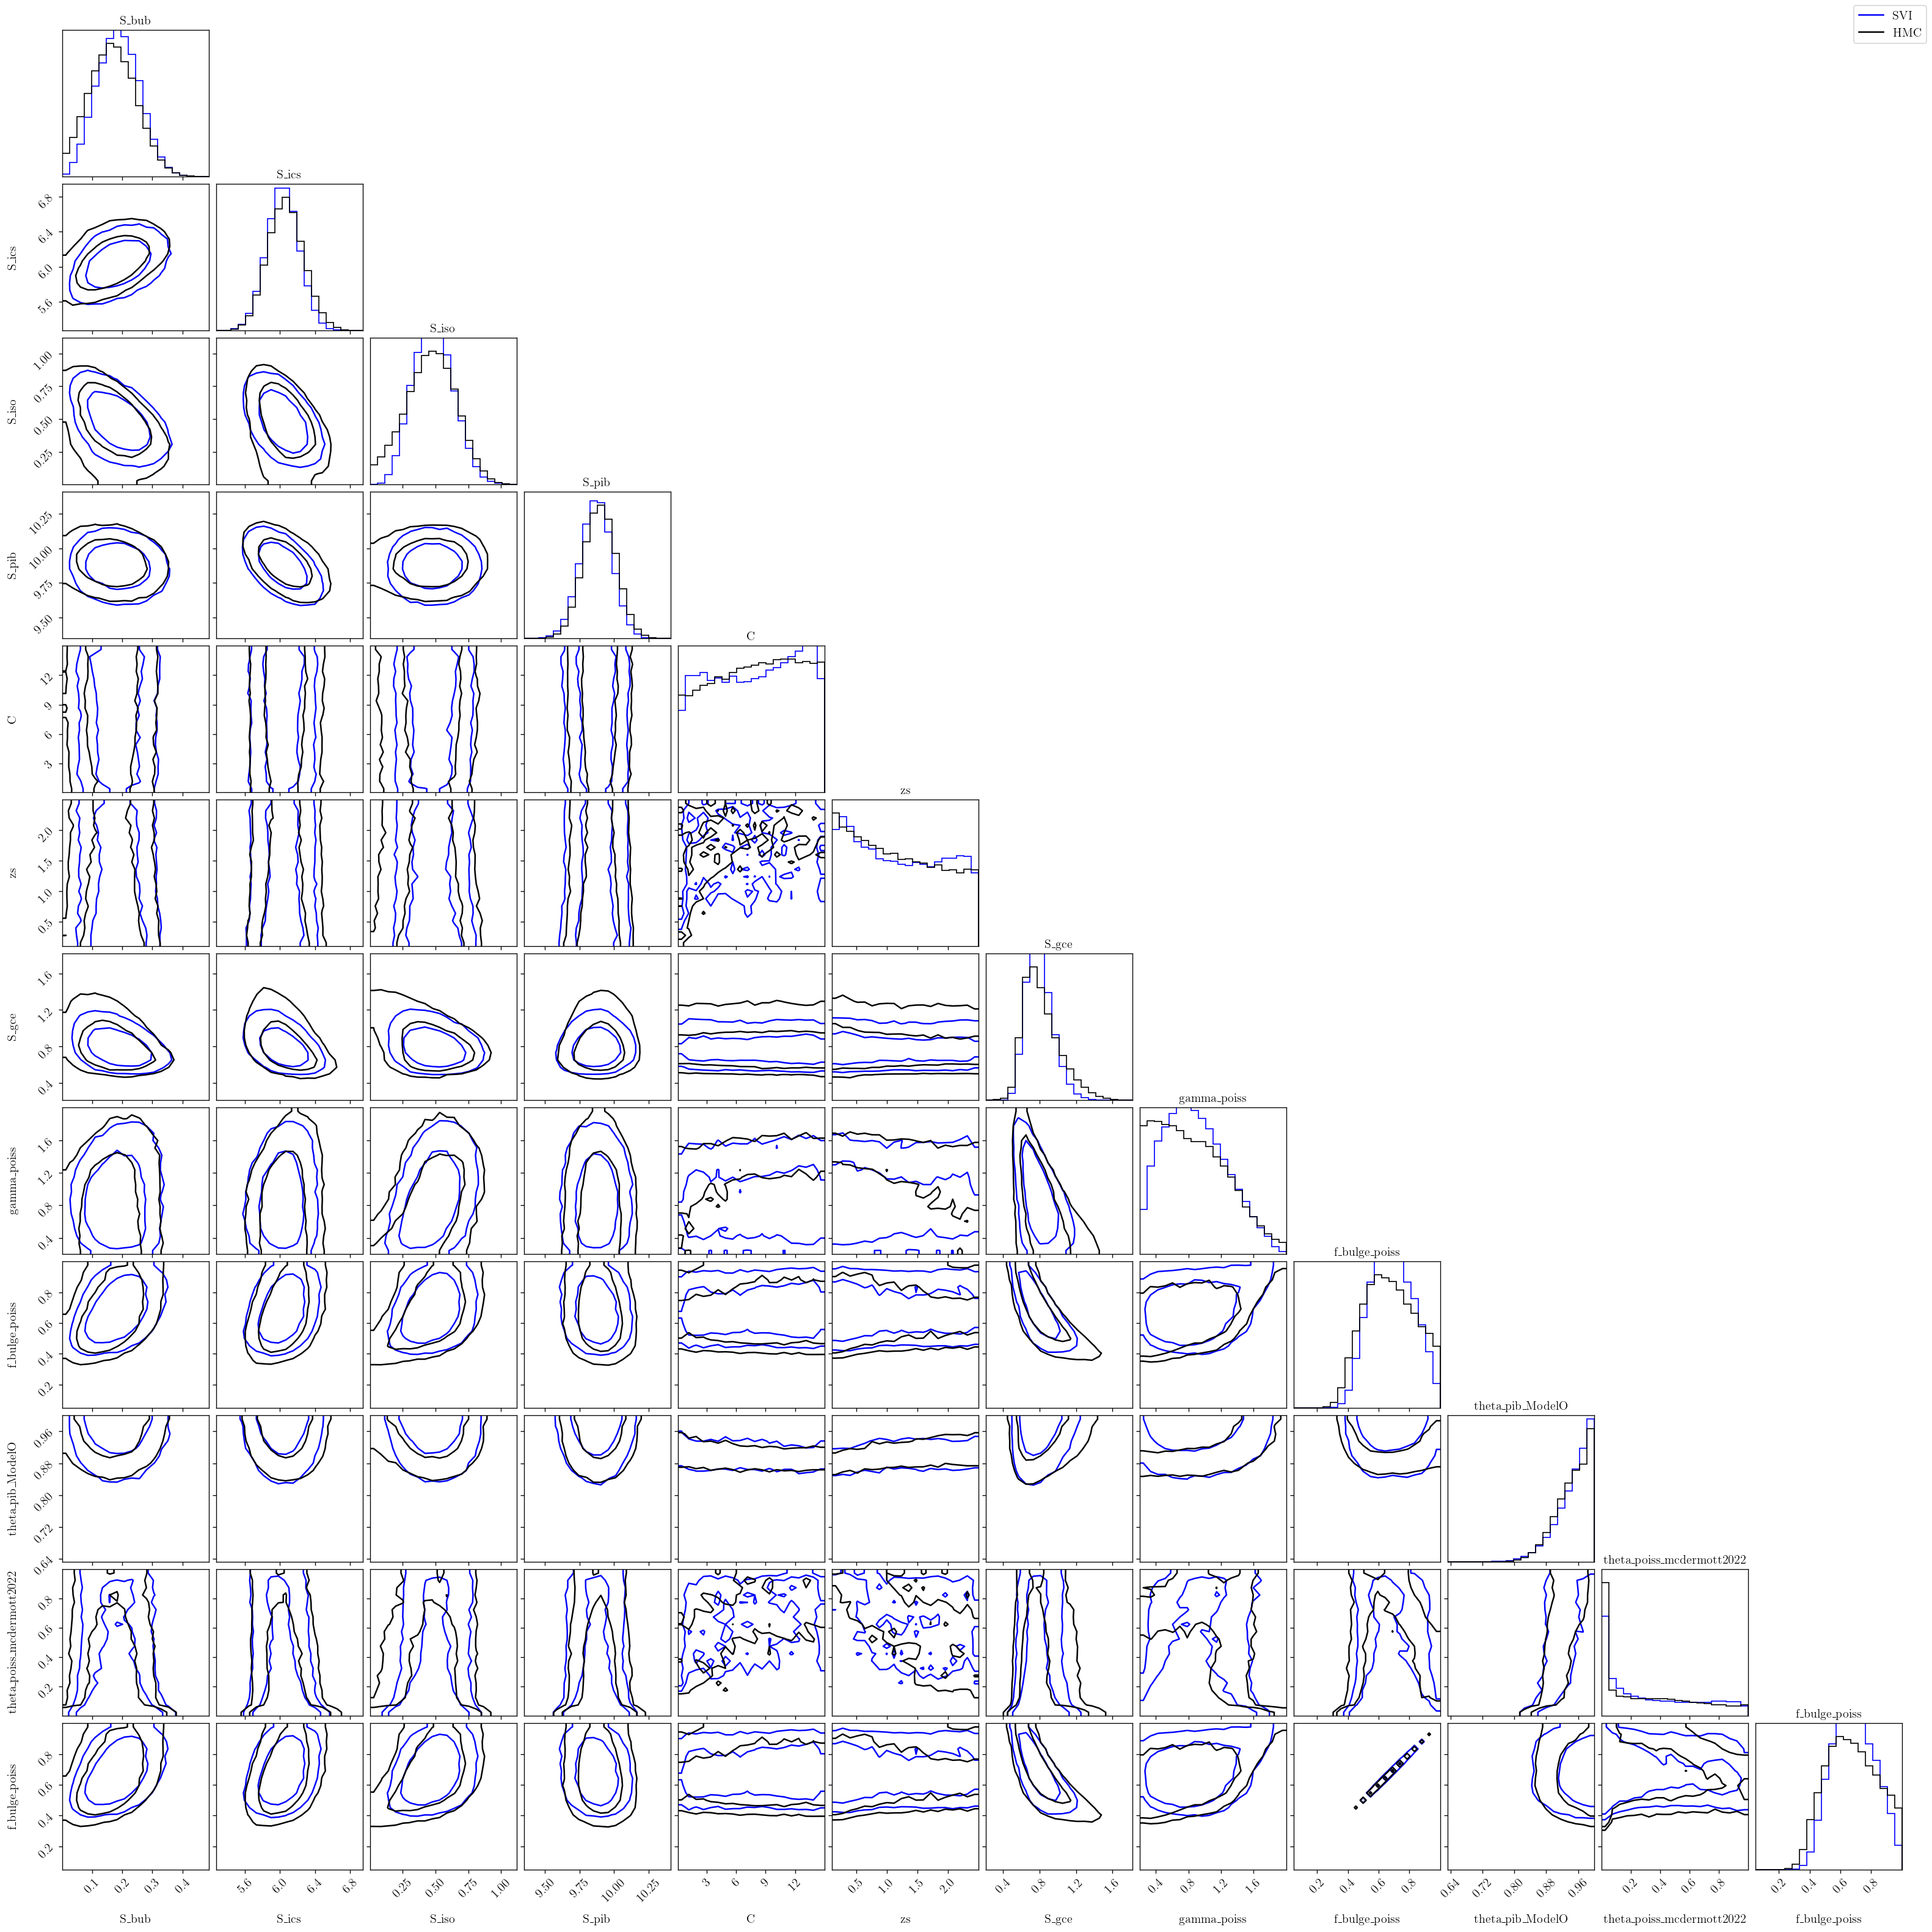

In [15]:
samples_dict = {
    'svi' : svi_samples,
    'hmc' : hmc_samples
}
colors_dict = {
    'svi' : 'b',
    'hmc' : 'k'
}
labels_dict = {
    'svi' : 'SVI',
    'hmc' : 'HMC'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_pib',
    'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_poiss_mcdermott2022', 'f_bulge_poiss'
]
logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1, save_fn=None
)